In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Kiran\.cache\kagglehub\datasets\yasserh\wine-quality-dataset\versions\1


In [38]:
 import os
import pandas as pd

# Construct the full path to the 'WineQT.csv' file (corrected filename)
file_path = os.path.join(path, 'WineQT.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
print("DataFrame loaded successfully. Displaying head:")
print(df.head())

DataFrame loaded successfully. Displaying head:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4  

In [39]:
print("Data types of each column:")
df.info()

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [40]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [41]:
print("Descriptive statistics for numerical columns:")
print(df.describe())

Descriptive statistics for numerical columns:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
mi

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) from the target variable (y)
X = df.drop(['quality', 'Id'], axis=1)
y = df['quality']

# 2. Apply StandardScaler to all feature columns in X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns) # Convert back to DataFrame to maintain column names

# 3. Split the scaled features (X) and the target variable (y) into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nDistribution of target variable in training set:\n", y_train.value_counts(normalize=True).sort_index())
print("\nDistribution of target variable in testing set:\n", y_test.value_counts(normalize=True).sort_index())

Shape of X_train: (914, 11)
Shape of X_test: (229, 11)
Shape of y_train: (914,)
Shape of y_test: (229,)

Distribution of target variable in training set:
 quality
3    0.005470
4    0.028446
5    0.422319
6    0.404814
7    0.124726
8    0.014223
Name: proportion, dtype: float64

Distribution of target variable in testing set:
 quality
3    0.004367
4    0.030568
5    0.423581
6    0.401747
7    0.126638
8    0.013100
Name: proportion, dtype: float64


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 2. Instantiate a LogisticRegression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and binary classification

# 3. Train the model
model.fit(X_train, y_train)

# 4. Make predictions on the X_test dataset
y_pred = model.predict(X_test)

# 5. Calculate and print the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

# 6. Calculate and print the confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.6463
Precision (weighted): 0.6119
Recall (weighted): 0.6463
F1-Score (weighted): 0.6090

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 81 16  0  0]
 [ 0  0 28 62  2  0]
 [ 0  0  3 21  5  0]
 [ 0  0  0  2  1  0]]


c:\Users\Kiran\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 2. Instantiate a LogisticRegression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and binary classification

# 3. Train the model
model.fit(X_train, y_train)

# 4. Make predictions on the X_test dataset
y_pred = model.predict(X_test)

# 5. Calculate and print the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

# 6. Calculate and print the confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.6463
Precision (weighted): 0.6119
Recall (weighted): 0.6463
F1-Score (weighted): 0.6090

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 81 16  0  0]
 [ 0  0 28 62  2  0]
 [ 0  0  3 21  5  0]
 [ 0  0  0  2  1  0]]


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Instantiate a RandomForestClassifier model
model_rf = RandomForestClassifier(random_state=42)

# 2. Train the model
model_rf.fit(X_train, y_train)

# 3. Make predictions on the X_test dataset
y_pred_rf = model_rf.predict(X_test)

# 4. Calculate and print the evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Classifier Precision (weighted): {precision_rf:.4f}")
print(f"Random Forest Classifier Recall (weighted): {recall_rf:.4f}")
print(f"Random Forest Classifier F1-Score (weighted): {f1_rf:.4f}")

# 5. Calculate and print the confusion_matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nRandom Forest Classifier Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Classifier Accuracy: 0.7205
Random Forest Classifier Precision (weighted): 0.6860
Random Forest Classifier Recall (weighted): 0.7205
Random Forest Classifier F1-Score (weighted): 0.6979

Random Forest Classifier Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 83 13  1  0]
 [ 0  0 21 68  3  0]
 [ 0  0  3 12 14  0]
 [ 0  0  0  2  1  0]]



Random Forest Feature Importances:
                 Feature  Importance
10               alcohol    0.150212
9              sulphates    0.115907
1       volatile acidity    0.106638
6   total sulfur dioxide    0.097958
7                density    0.087983
4              chlorides    0.078689
0          fixed acidity    0.077977
2            citric acid    0.077131
8                     pH    0.077033
3         residual sugar    0.065486
5    free sulfur dioxide    0.064986



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\Kiran\AppData\Local\Temp\ipykernel_56348\2687182630.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


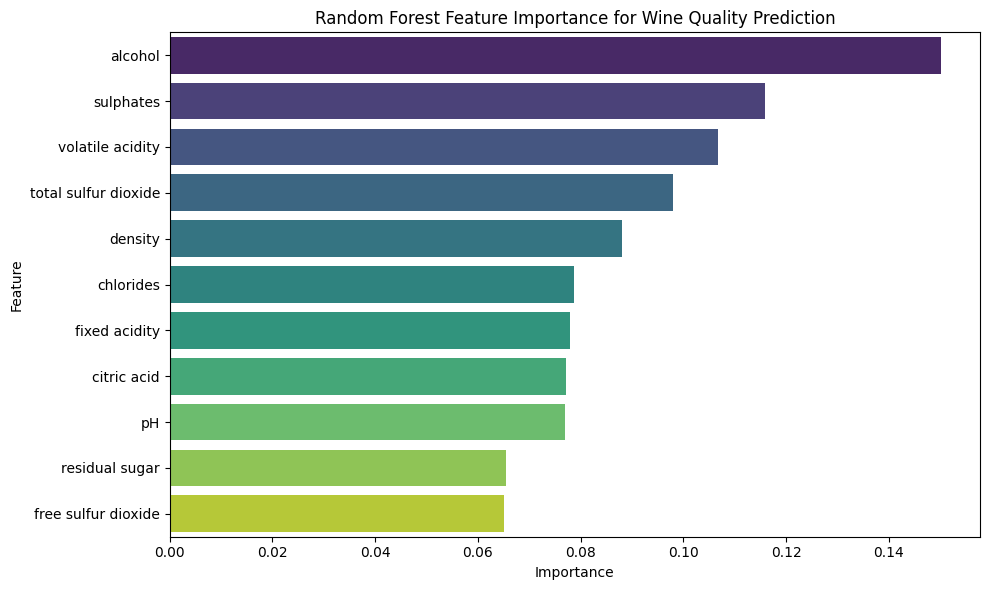

In [46]:
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure RandomForest model exists; if not, (re)train using X_train and y_train
if 'model_rf' not in globals():
	from sklearn.ensemble import RandomForestClassifier
	model_rf = RandomForestClassifier(random_state=42)
	model_rf.fit(X_train, y_train)

# Get feature importances from the Random Forest model
feature_importances = model_rf.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization and sorting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importances:")
print(importance_df)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance for Wine Quality Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [52]:
# Compute metrics for missing models (Decision Tree, SGD, SVC) then build summary table.
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Decision Tree: use existing clf if available, otherwise create one
if 'clf' in globals():
    dt_model = clf
else:
    dt_model = DecisionTreeClassifier(random_state=42)
# Fit (safe to re-fit)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

# SGD Classifier
sgd_clf = SGDClassifier(random_state=42, max_iter=1000, tol=1e-3)
sgd_clf.fit(X_train, y_train)
y_pred_sgd = sgd_clf.predict(X_test)
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)
precision_sgd = precision_score(y_test, y_pred_sgd, average='weighted', zero_division=0)
recall_sgd = recall_score(y_test, y_pred_sgd, average='weighted', zero_division=0)
f1_sgd = f1_score(y_test, y_pred_sgd, average='weighted', zero_division=0)

# SVC
svc_clf = SVC(random_state=42)
svc_clf.fit(X_train, y_train)
y_pred_svc = svc_clf.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc, average='weighted', zero_division=0)
recall_svc = recall_score(y_test, y_pred_svc, average='weighted', zero_division=0)
f1_svc = f1_score(y_test, y_pred_svc, average='weighted', zero_division=0)

# Create a dictionary to store the metrics for each model
metrics_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SGD Classifier', 'SVC Classifier'],
    'Accuracy': [accuracy, accuracy_dt, accuracy_rf, accuracy_sgd, accuracy_svc],
    'Precision (weighted)': [precision, precision_dt, precision_rf, precision_sgd, precision_svc],
    'Recall (weighted)': [recall, recall_dt, recall_rf, recall_sgd, recall_svc],
    'F1-Score (weighted)': [f1, f1_dt, f1_rf, f1_sgd, f1_svc]
}

# Create a DataFrame from the metrics data
metrics_df = pd.DataFrame(metrics_data)

# Sort by Accuracy for better readability
metrics_df = metrics_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("Model Performance Summary:")
print(metrics_df.round(4))

Model Performance Summary:
                 Model  Accuracy  Precision (weighted)  Recall (weighted)  \
0        Random Forest    0.7205                0.6860             0.7205   
1       SVC Classifier    0.6638                0.6324             0.6638   
2  Logistic Regression    0.6463                0.6119             0.6463   
3        Decision Tree    0.5895                0.5495             0.5895   
4       SGD Classifier    0.5284                0.5422             0.5284   

   F1-Score (weighted)  
0               0.6979  
1               0.6382  
2               0.6090  
3               0.5482  
4               0.5195  


Analyzing features: ['fixed acidity', 'volatile acidity', 'citric acid', 'pH', 'density']

Correlation with quality:
 volatile acidity   -0.4074
citric acid         0.2408
density            -0.1752
fixed acidity       0.1220
pH                 -0.0525
Name: quality, dtype: float64


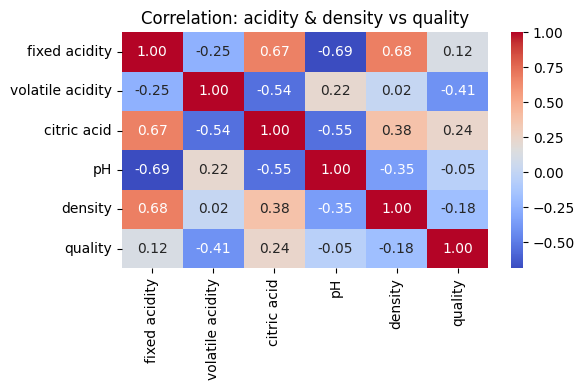

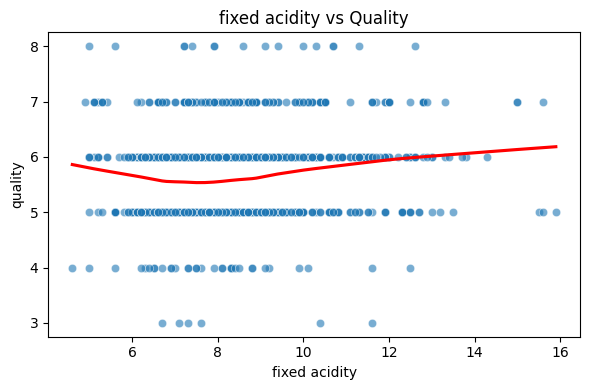

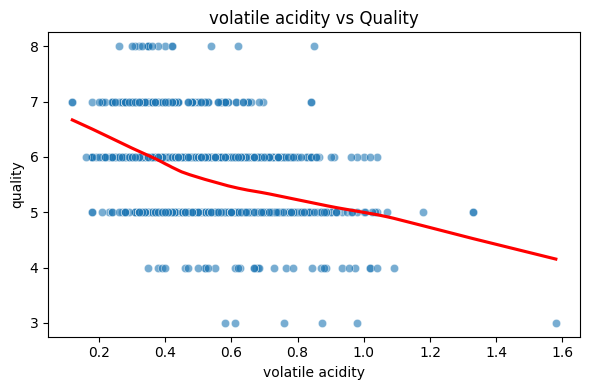

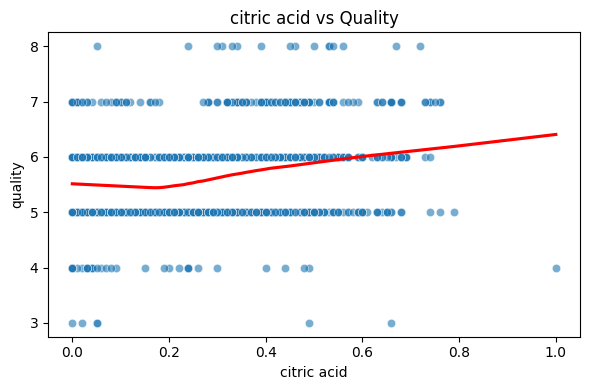

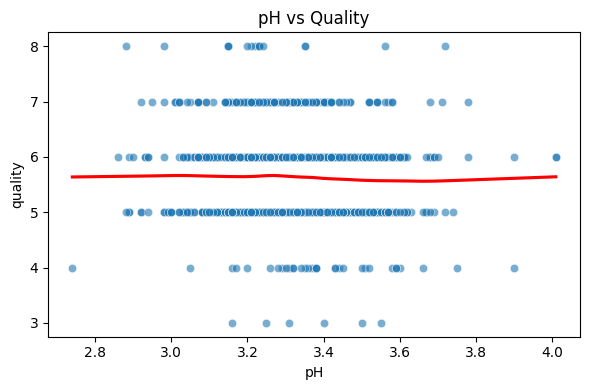

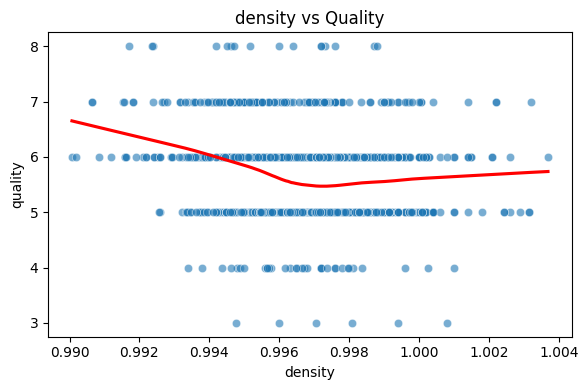

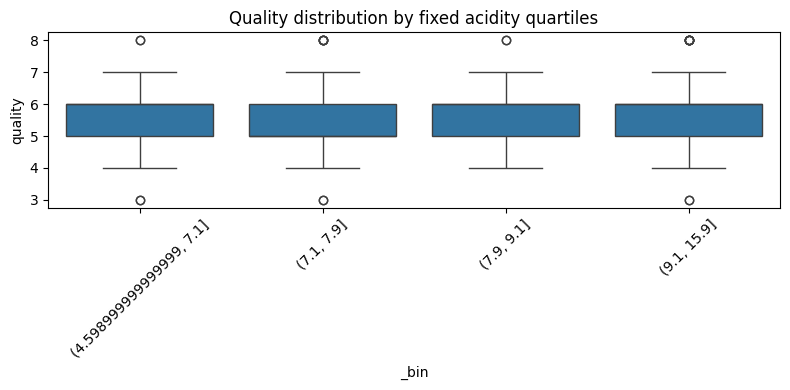

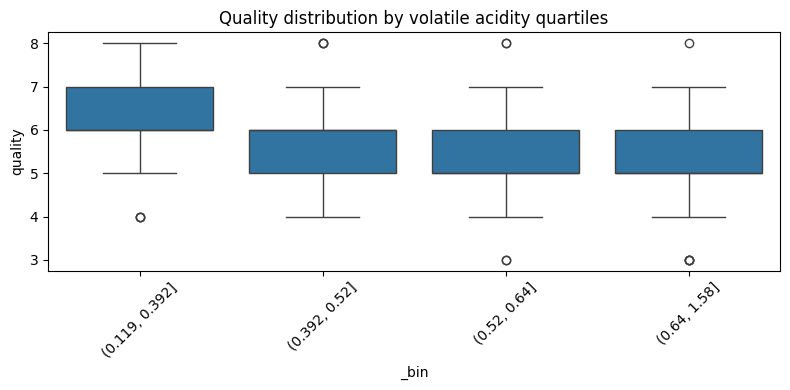

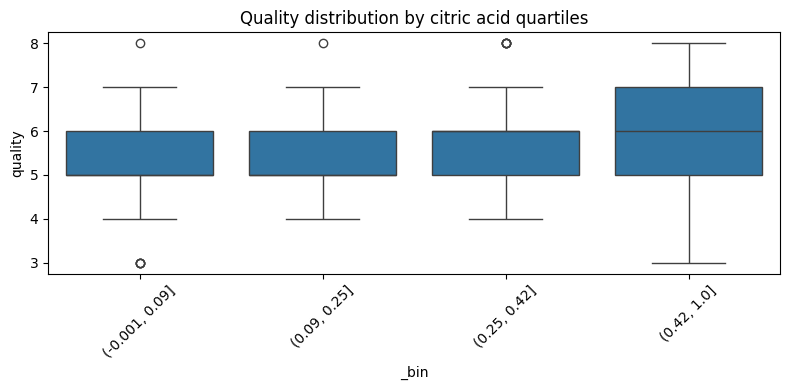

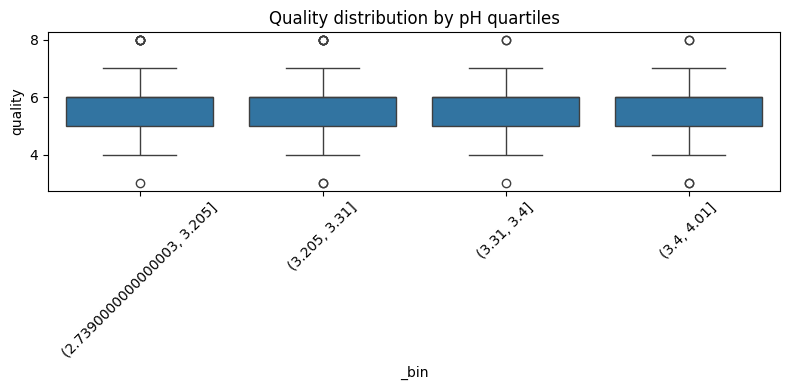

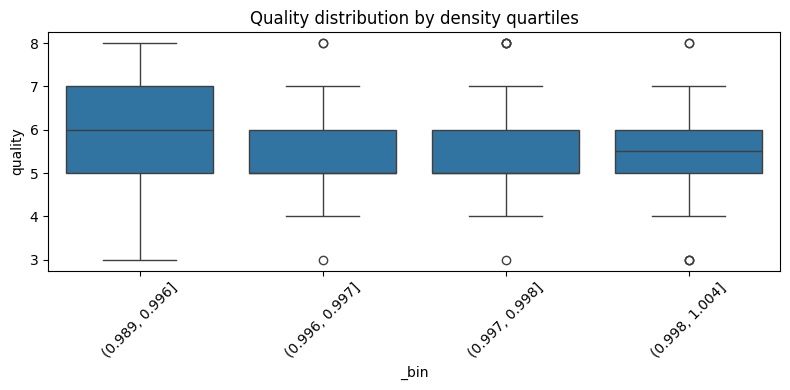

DecisionTree (features: ['fixed acidity', 'volatile acidity', 'citric acid', 'pH', 'density']) CV accuracy: 0.4891 ± 0.0532


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Features to analyze
feat_acidity = ['fixed acidity','volatile acidity','citric acid','pH','density']
available = [f for f in feat_acidity if f in df.columns]
print('Analyzing features:', available)

# Correlation with quality
corrs = df[available + ['quality']].corr()['quality'].drop('quality').sort_values(key=abs, ascending=False)
print('\nCorrelation with quality:\n', corrs.round(4))

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[available + ['quality']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: acidity & density vs quality')
plt.tight_layout()
plt.show()

# Scatter plots with smoothed trend
for f in available:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[f], y=df['quality'], alpha=0.6)
    sns.regplot(x=df[f], y=df['quality'], scatter=False, lowess=True, color='red')
    plt.title(f"{f} vs Quality")
    plt.tight_layout()
    plt.show()

# Boxplots by quartiles
for f in available:
    df['_bin'] = pd.qcut(df[f], q=4, duplicates='drop')
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df['_bin'], y=df['quality'])
    plt.xticks(rotation=45)
    plt.title(f"Quality distribution by {f} quartiles")
    plt.tight_layout()
    plt.show()
df.drop(columns=['_bin'], inplace=True, errors='ignore')

# Simple model using only these features
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
X_small = df[available]
y = df['quality']
clf = DecisionTreeClassifier(random_state=42, max_depth=3)
scores = cross_val_score(clf, X_small, y, cv=5, scoring='accuracy')
print(f"DecisionTree (features: {available}) CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


In [50]:
import numpy as np

# Pandas / NumPy examples for data manipulation and array ops
print('Pandas version:', pd.__version__)
print('NumPy version:', np.__version__)

# 1) Create a small derived feature set using vectorized operations
df['acidity_sum'] = df[['fixed acidity','volatile acidity','citric acid']].sum(axis=1)
df['acid_density_ratio'] = df['acidity_sum'] / df['density']

print('\nDerived features head:')
print(df[['acidity_sum','acid_density_ratio']].head())

# 2) Grouped aggregate: mean quality by rounded density
df['density_round'] = df['density'].round(3)
grouped = df.groupby('density_round')['quality'].agg(['mean','count'])
print('\nQuality by rounded density (top 10 rows):')
print(grouped.sort_values('count', ascending=False).head(10))

# 3) Vectorized filtering and boolean indexing with NumPy
mask = (df['acid_density_ratio'] > df['acid_density_ratio'].median()) & (df['quality'] >= 6)
selected = df.loc[mask, ['fixed acidity','volatile acidity','density','quality']]
print(f"\nRows with high acid_density_ratio and quality>=6: {selected.shape[0]}")

# 4) Convert a column to a NumPy array and run a simple operation
arr = df['quality'].to_numpy()
print('\nQuality array stats: mean=', np.mean(arr), 'std=', np.std(arr))

# 5) Demonstrate using NumPy broadcasting to normalize a small matrix
mat = df[['fixed acidity','volatile acidity','citric acid']].to_numpy()[:10]
mat_norm = (mat - np.mean(mat, axis=0)) / (np.std(mat, axis=0) + 1e-9)
print('\nFirst 3 rows of normalized acid matrix:\n', mat_norm[:3])


Pandas version: 2.1.3
NumPy version: 1.26.4

Derived features head:
   acidity_sum  acid_density_ratio
0         8.10            8.117859
1         8.68            8.707865
2         8.60            8.625878
3        12.04           12.064128
4         8.10            8.117859

Quality by rounded density (top 10 rows):
                   mean  count
density_round                 
0.996          5.528302    265
0.997          5.571429    259
0.998          5.441176    170
0.995          5.967532    154
0.999          5.683673     98
0.994          5.983871     62
1.000          5.607143     56
0.993          5.888889     27
0.992          6.647059     17
1.001          5.384615     13

Rows with high acid_density_ratio and quality>=6: 321

Quality array stats: mean= 5.657042869641295 std= 0.805471666920189

First 3 rows of normalized acid matrix:
 [[-0.40509716  0.41305887 -0.46438253]
 [-0.06033362  1.63192112 -0.46438253]
 [-0.06033362  0.81934629 -0.21997067]]
